#### **FACTIBILIDAD DE LA SOLUCIÓN**

In [551]:
import pandas as pd 
import matplotlib.pyplot as plt
from importlib import reload

import Clases.caja as caja_module
reload(caja_module)
from Clases.caja import Caja

import Clases.producto as producto_module
reload(producto_module)
from Clases.producto import Producto

catalogo_productos = pd.read_csv("Datos-finales/catalogo_productos.csv")
especificaciones_cajas = pd.read_csv("Datos-finales/especificaciones_cajas.csv")
operaciones_planta = pd.read_csv("Datos-finales/operaciones_planta.csv")
procurement_cajas = pd.read_csv("Datos-finales/procurement_cajas.csv")

Guardamos primero los tipos de cajas y productos en listas de python.

In [552]:
caja_compras_merge = especificaciones_cajas.merge(procurement_cajas,
                                                  on="caja_tipo_id")

cajas = [
    Caja(
        caja_id = row["caja_tipo_id"],
        dim_interior_ancho = row["caja_interior_ancho"],
        dim_interior_largo = row["caja_interior_largo"],
        dim_interior_alto = row["caja_interior_alto"],
        compra_buenos_aires = row['volumen_tipo_planta_buenos_aires'],
        compra_curitiba = row['volumen_tipo_planta_curitiba'],
        compra_santiago = row['volumen_tipo_planta_santiago'],
        compra_monterrey = row['volumen_tipo_planta_monterrey'],
        compra_bakersfield = row['volumen_tipo_planta_bakersfield'],
        costo_unitario = row['costo_unitario_base']
    )
    for _, row in caja_compras_merge.iterrows()
]

cajas[:5]

[<Caja 016d196c89dcfcb306b853a776a879b9 | Int: 248.0x383.0x224.0mm>,
 <Caja 01a2a319402ed2155292c04d8748e16f | Int: 282.0x380.0x185.0mm>,
 <Caja 026560e43f3fc6afe0ce89d7ddf61626 | Int: 290.0x390.0x184.0mm>,
 <Caja 02d7c6680102bd11e067c00c9b71ab9c | Int: 248.0x383.0x268.0mm>,
 <Caja 0378f85c226113f4ac40fd360217bb8a | Int: 289.0x390.0x224.0mm>]

In [553]:
operaciones_planta_aux = operaciones_planta.drop('codigo_producto', axis=1) 
prod_op_merge = pd.concat([catalogo_productos, operaciones_planta_aux], axis=1)

productos = [
    Producto(
        codigo_producto = row['codigo_producto'],
        cantidad_paquetes = row['cantidad_paquetes'],
        peso_paquete = row['peso_neto_paquete'],
        produccion_buenos_aires = row['volumen_producto_planta_buenos_aires'],
        produccion_curitiba = row['volumen_producto_planta_curitiba'],
        produccion_santiago = row['volumen_producto_planta_santiago'],
        produccion_monterrey = row['volumen_producto_planta_monterrey'],
        produccion_bakersfield = row['volumen_producto_planta_bakersfield'],
        dim_producto_ancho = row['dim_producto_ancho'], 
        dim_producto_largo = row['dim_producto_largo'],
        dim_producto_alto = row['dim_producto_alto']
    )
    for _, row in prod_op_merge.iterrows()
]

productos[:5]

[<Producto BR0001 | Dim Prod: 285.0x386.0x303.0mm | Volumen Total: 1546613>,
 <Producto BR0002 | Dim Prod: 290.0x390.0x260.0mm | Volumen Total: 139211>,
 <Producto BR0003 | Dim Prod: 287.0x388.0x164.0mm | Volumen Total: 172506>,
 <Producto BR0004 | Dim Prod: 290.0x390.0x224.0mm | Volumen Total: 271715>,
 <Producto BR0005 | Dim Prod: 285.0x386.0x253.0mm | Volumen Total: 7586>]

#### **Factibilidad 1: Tipos de cajas asignables por dimensión**

La idea sería ver cuántos tipos de cajas se pueden asignar por producto, considerando la restricción de cada dimensión interna. Sabemos que volumen_interno >= volumen_producto, y que además cada dimensión interna no puede superar más del 10% de la original.

In [554]:
cajas_asignables_dimension = {}

for producto in productos:
    cajas_asignables = []
    for caja in cajas:
        if caja.es_asignable_por_dimension(producto):
            cajas_asignables.append(caja)
    
    cajas_asignables_dimension[producto] = cajas_asignables

Veamos en detalle cuántos tipos de cajas son asignables por cada producto.

In [555]:
df_dimension = pd.DataFrame([
    {
        'codigo_producto': producto.codigo_producto,
        'cantidad_cajas_asignables': len(cajas_asign),
    }
    for producto, cajas_asign in cajas_asignables_dimension.items()
])

df_dimension = df_dimension.sort_values('cantidad_cajas_asignables', ascending=False)
df_dimension

,codigo_producto,cantidad_cajas_asignables
326,BR0317,24
325,BR0316,24
104,BR0103,22
29,BR0030,21
291,BR0284,21
...,...,...
123,BR0122,1
115,BR0114,1
57,BR0058,1
358,BR0345,1


Observemos que el espacio de búsqueda se redujo significativamente, y como máximo se pueden asignar 24 tipos de cajas a un mismo producto, siendo el caso de BR0317. 

Veamos cómo se distribuye esta cantidad en un gráfico.

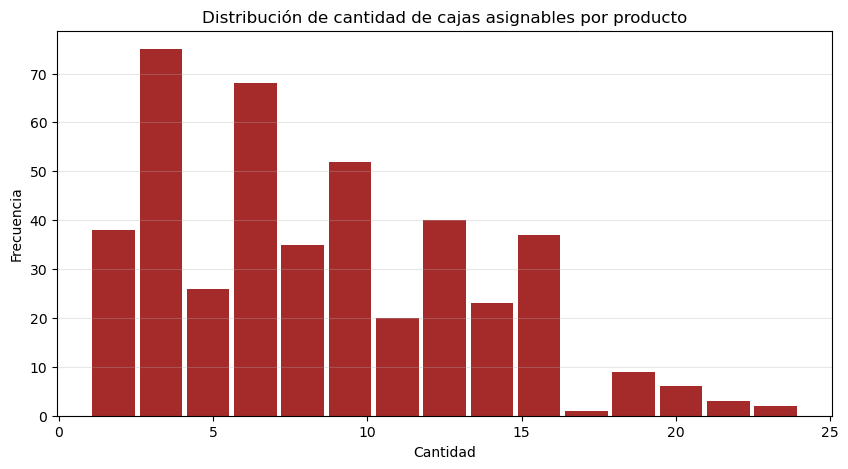

In [556]:
plt.figure(figsize=(10, 5))
plt.hist(df_dimension['cantidad_cajas_asignables'].dropna(), bins=15,
         color='brown', rwidth=0.9)
plt.title('Distribución de cantidad de cajas asignables por producto')
plt.xlabel('Cantidad')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.3)
plt.show()

Podemos notar que la mayoría de productos suelen poder utilizar hasta 10 tipos de cajas, y que sólo pocos casos alcanzan hasta los 20 o más. Esto nos genera definitivamente una gran ventaja en la optimización posterior.

#### **Factibilidad 2: Volumen alcanzable**

Sigamos reduciendo el espacio de búsqueda. Lo segundo que tendremos en cuenta es que la compra de un tipo de caja debe ser superior (o al menos igual) al volumen del producto asociado a esa caja.

In [557]:
cajas_asignables_volumen = {}

for producto in productos:
    cajas_asignables = []
    for caja in cajas_asignables_dimension[producto]:
        if caja.unidades_total() >= producto.produccion_total():
            cajas_asignables.append(caja)
    
    cajas_asignables_volumen[producto] = cajas_asignables

df_volumen = pd.DataFrame([
    {
        'codigo_producto': producto.codigo_producto,
        'cantidad_cajas_asignables': len(cajas_asign),
    }
    for producto, cajas_asign in cajas_asignables_volumen.items()
])

df_volumen = df_volumen.sort_values('cantidad_cajas_asignables', ascending=False)
df_volumen

,codigo_producto,cantidad_cajas_asignables
29,BR0030,18
328,BR0319,18
347,BR0336,17
247,BR0241,17
35,BR0036,17
...,...,...
44,BR0045,1
393,BR0380,1
57,BR0058,1
6,BR0007,1


El espacio de búsqueda se redujo nuevamente!

Además, para aquellos productos que tienen únicamente un tipo de caja asignable, les asignamos esa caja para analizar si la disminución del volumen de tipos de cajas afecta en la cantidad de cajas asignables para los demás productos.

In [558]:
productos_a_eliminar = []

for producto, cajas in cajas_asignables_volumen.items():
    if len(cajas) == 1:
        caja = cajas[0]
        caja.asignar_producto(producto)
        productos_a_eliminar.append(producto)

cajas_ya_asignados = {}

# Eliminamos el producto dentro de la lista porque ya elegimos su tipo de caja
for producto in productos_a_eliminar:
    caja = cajas_asignables_volumen[producto][0]
    cajas_ya_asignados[producto] = caja
    cajas_asignables_volumen.pop(producto) 

Veamos ahora cuántos tipos de cajas se asignan a los demás productos.

In [559]:
for producto, cajas in cajas_asignables_volumen.items():
    cajas_asignables = []
    for caja in cajas:
        if caja.unidades_total() >= producto.produccion_total():
            cajas_asignables.append(caja)
    cajas_asignables_volumen[producto] = cajas_asignables

df_volumen = pd.DataFrame([
    {
        'codigo_producto': producto.codigo_producto,
        'cantidad_cajas_asignables': len(cajas_asign),
    }
    for producto, cajas_asign in cajas_asignables_volumen.items()
])

df_volumen = df_volumen.sort_values('cantidad_cajas_asignables', ascending=False)
df_volumen

,codigo_producto,cantidad_cajas_asignables
27,BR0030,18
302,BR0319,18
319,BR0336,17
229,BR0241,17
33,BR0036,17
...,...,...
356,BR0372,2
357,BR0373,2
10,BR0013,2
2,BR0004,2


Efectivamente, la utilización de dichos tipos de cajas hicieron que demás productos se viesen obligados a reducir su cantidad de cajas asignables.

Observemos que incluso algunos productos empezaron a poder utilizar también únicamente un tipo de caja. Iteremos nuevamente lo hecho.

In [560]:
productos_a_eliminar = []

for producto, cajas in cajas_asignables_volumen.items():
    if len(cajas) == 1:
        caja = cajas[0]
        caja.asignar_producto(producto)
        productos_a_eliminar.append(producto)

for producto in productos_a_eliminar:
    caja = cajas_asignables_volumen[producto][0]
    cajas_ya_asignados[producto] = caja
    cajas_asignables_volumen.pop(producto) 

for producto, cajas in cajas_asignables_volumen.items():
    cajas_asignables = []
    for caja in cajas:
        if caja.unidades_total() >= producto.produccion_total():
            cajas_asignables.append(caja)
    cajas_asignables_volumen[producto] = cajas_asignables

df_volumen = pd.DataFrame([
    {
        'codigo_producto': producto.codigo_producto,
        'cantidad_cajas_asignables': len(cajas_asign),
    }
    for producto, cajas_asign in cajas_asignables_volumen.items()
])

df_volumen = df_volumen.sort_values('cantidad_cajas_asignables', ascending=False)
df_volumen

,codigo_producto,cantidad_cajas_asignables
27,BR0030,18
302,BR0319,18
319,BR0336,17
229,BR0241,17
33,BR0036,17
...,...,...
356,BR0372,2
357,BR0373,2
10,BR0013,2
2,BR0004,2


Una vez terminado de iterar la factibilidad por volumen, veamos cómo se distribuye ahora la cantidad de tipos de cajas asignables por producto, y comparemos con lo que teníamos anteriormente tras la factibilidad por dimensión.

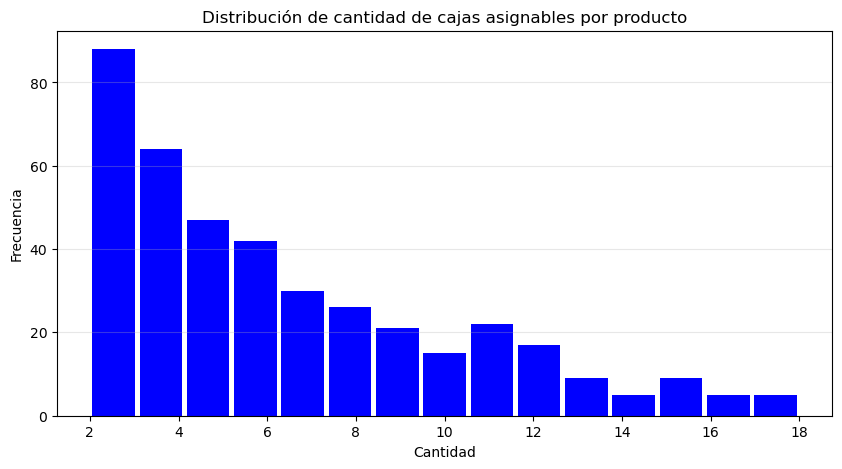

In [561]:
plt.figure(figsize=(10, 5))
plt.hist(df_volumen['cantidad_cajas_asignables'].dropna(), bins=15,
         color='blue', rwidth=0.9)
plt.title('Distribución de cantidad de cajas asignables por producto')
plt.xlabel('Cantidad')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.3)
plt.show()

Bien! Ahora la distribución muestra que el espacio de búsqueda es muchísimo más chico. La mayoría de productos pueden utilizar solamente hasta 5 tipos de cajas, y como máximo hasta 18.

In [562]:
cajas_totales = set()

for producto, cajas in cajas_asignables_volumen.items():
    for c in cajas:
        cajas_totales.add(c)

print(f"Quedan {len(cajas_totales)}/{len(especificaciones_cajas)} tipos de caja asignables.")

Quedan 203/204 tipos de caja asignables.


Por otro lado, notemos que al asignar a algunos productos su tipo de caja único, llegamos a reducir la cantidad de tipos de cajas totales que quedan por asignar (exactamente 17).

Exportemos los resultados a csv:

In [563]:
datos = []

for producto, cajas in cajas_asignables_volumen.items():
    ids_cajas = [caja.caja_id for caja in cajas]  
    datos.append({
        'codigo_producto': producto.codigo_producto,
        'produccion_total': producto.produccion_total(),
        'cajas_asignables_id': '; '.join(ids_cajas)  # Unir con ;
    })

for producto, caja in cajas_ya_asignados.items():
    datos.append({
        'codigo_producto': producto.codigo_producto,
        'produccion_total': producto.produccion_total(),
        'cajas_asignables_id': caja.caja_id
    })

df_cajas_asignables = pd.DataFrame(datos)
df_cajas_asignables.to_csv('4r.factibilidad.csv', index=False)